# DMO[1-n] -> Fatigue[n] (daily)
This will take all n visits for each patient and concat them together so that it only predicts the final value

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.evaluation import Evaluation
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from src.core.data_transforms import Transform
from src.model import DMORandomForestRegressor

import numpy as np
import torch
import shap

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
K_FOLDS = 5
N_VISITS = 4

In [3]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [4]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [6]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [7]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = torch.tensor(dmo_data[patient_indexs])
dmo_labels = torch.tensor(dmo_labels[patient_indexs])

/tmp/ipykernel_635509/2059235607.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dmo_data = torch.tensor(dmo_data[patient_indexs])
/tmp/ipykernel_635509/2059235607.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dmo_labels = torch.tensor(dmo_labels[patient_indexs])


In [8]:
print(dmo_data.shape)

torch.Size([428, 4, 7, 24])


In [9]:
dmo_data = dmo_data.flatten(start_dim=2, end_dim=3)

In [10]:
# shuffle
patients, *other = dmo_data.shape
generator = torch.Generator()
generator.manual_seed(1234)
random_permutation = torch.randperm(patients, generator=generator)

dmo_data = dmo_data[random_permutation]
dmo_labels = dmo_labels[random_permutation]

In [11]:
dmo_data.shape

torch.Size([428, 4, 168])

In [12]:
dmo_labels.shape

torch.Size([428, 4, 1])

In [13]:
# Min max normalise the labels globally

label_normaliser = Normaliser(MinMaxScaler())
dmo_labels = label_normaliser.scaler_fit_transform(dmo_labels)

In [14]:
# shuffle with fixed seed
patients, visits, features = dmo_data.shape
generator = torch.Generator()
generator.manual_seed(1234)
random_permutation = torch.randperm(patients, generator=generator)

dmo_data = dmo_data[random_permutation]
dmo_labels = dmo_labels[random_permutation]


In [15]:
dmo_data_split = torch.tensor_split(dmo_data, K_FOLDS)
dmo_label_split = torch.tensor_split(dmo_labels, K_FOLDS)

prediction_arr = []
actual_arr = []
shap_values = []
test_inputs = []
baseline_values = []

for split_i in range(K_FOLDS):
    test_label = dmo_label_split[split_i]
    test_data = dmo_data_split[split_i]

    train_label = torch.cat(
        [dmo_label_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    train_data = torch.cat(
        [dmo_data_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    
    test_data = test_data.flatten(start_dim=1, end_dim=2)
    test_label = test_label.flatten(start_dim=1, end_dim=2)[:, -1]
    
    train_data = train_data.flatten(start_dim=1, end_dim=2)
    train_label = train_label.flatten(start_dim=1, end_dim=2)[:, -1]
    
    # normalise data
    scaler = StandardScaler()
    scaler.fit(train_data)
    
    train_data = scaler.transform(train_data)
    test_data = scaler.transform(test_data)
    
    rf_model = DMORandomForestRegressor(n_trees=500)

    rf_model.train(train_data, train_label)
    score = rf_model.score(test_data, test_label)
    print(score)
    
    prediction = torch.tensor(rf_model.predict(test_data))
    prediction = label_normaliser.scaler_inverse_labels(prediction)
    
    actual = label_normaliser.scaler_inverse_labels(test_label)
    
    prediction_arr.append(prediction)
    actual_arr.append(actual)
    
    sklearn_rf_model = rf_model.random_forest
    
    test_input_numpy = test_data
    explainer = shap.TreeExplainer(sklearn_rf_model)
    shap_value = explainer.shap_values(test_input_numpy)
    shap_values.append(shap_value)
    test_inputs.append(test_data)
    baseline_values.append(explainer.expected_value)
    

0.18684516704019216
0.15574731660995522
0.19225828754371854
0.1520108673611852
0.05194922866663654


In [16]:
prediction = torch.cat(prediction_arr)
actual = torch.cat(actual_arr)

In [17]:
prediction

tensor([18.9680, 21.7120, 17.7480, 13.8280, 19.8940, 21.2860, 22.0600, 22.6660,
        23.9420, 23.1520, 21.8340, 22.1060, 15.4000, 17.2900, 16.7360, 21.0140,
        19.9760, 25.2120, 19.9380, 14.9640, 19.5680, 23.0540, 20.3200, 21.0380,
        19.7060, 19.6900, 22.2520, 21.9900, 22.0020, 21.7240, 24.2900, 22.3460,
        21.8160, 24.4080, 21.4880, 16.0440, 20.5640, 21.0660, 18.6380, 24.2900,
        20.4900, 22.7500, 21.2660, 17.4480, 22.2540, 23.7100, 13.4580, 22.5300,
        16.1900, 22.7180, 16.5100, 21.8680, 20.3860, 18.6880, 22.6120, 20.4360,
        23.3620, 24.1200, 21.5920, 21.6540, 22.3000, 22.1240, 21.9780, 15.2240,
        21.3820, 15.2660, 22.2520, 14.9860, 16.2120, 20.4940, 15.5460, 19.7400,
        19.3040, 25.3720, 12.0320, 23.6520, 17.2440, 22.0440, 18.9260, 19.4620,
        23.7280, 23.7720, 24.7720, 20.4680, 18.4380, 17.4840, 19.0320, 21.9240,
        23.1020, 20.8920, 22.7620, 23.0660, 24.1840, 21.7700, 21.3340, 19.4620,
        13.7880, 16.6700, 20.0680, 21.29

{'accuracy': 0.009345794392523364, 'Mean Squared Error': 59.61174011230469, 'Mean Absolute Error': 6.224481105804443, 'R^2': 0.1577062305361746}


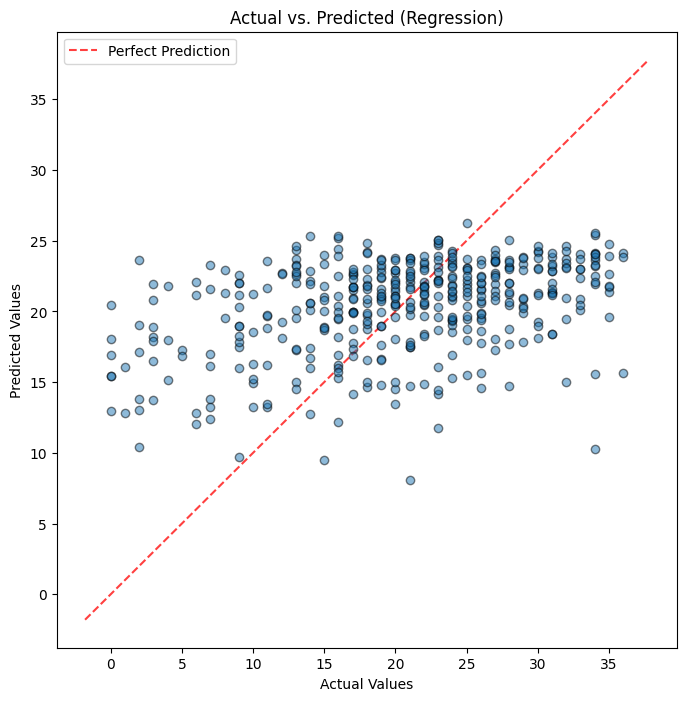

In [18]:
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()

In [19]:
import shap

random_forest_model = rf_model.random_forest
test_input_numpy = torch.Tensor.numpy(test_data)

explainer = shap.TreeExplainer(random_forest_model)
shap_values = explainer.shap_values(test_input_numpy)
shap.summary_plot(shap_values, test_input_numpy, feature_names=dmo_features * 5)

TypeError: descriptor 'numpy' for 'torch._C.TensorBase' objects doesn't apply to a 'numpy.ndarray' object